In [6]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from envs import *
from reinforce import *
import torch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# TP1 - Gradiente de Política

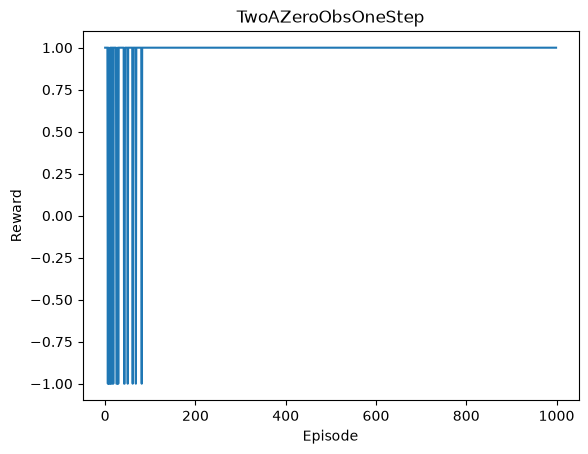

In [7]:
env = TwoAZeroObsOneStep()

policy, history = train_reinforce(
    env,
    num_episodes=1000,
    batch_size=10,
    gamma=0.99,
    learning_rate=1e-2,
)

plt.plot(history["rewards"])
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("TwoAZeroObsOneStep")
plt.show()

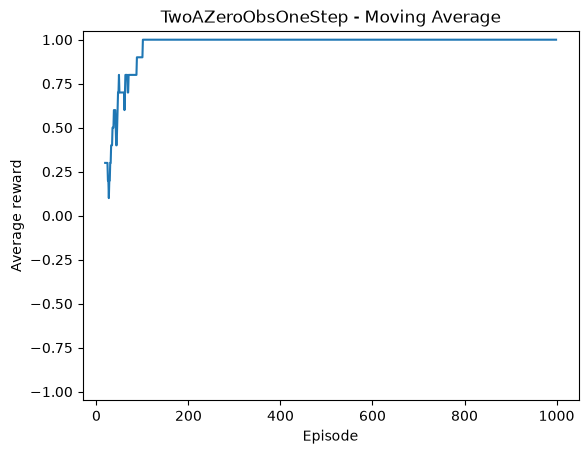

In [8]:
rewards = np.array(history["rewards"])

window = 20

moving_avg = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    np.arange(window - 1, len(rewards)),
    moving_avg
)

plt.xlabel("Episode")
plt.ylabel("Average reward")
plt.title("TwoAZeroObsOneStep - Moving Average")
plt.ylim(-1.05, 1.05)
plt.show()

In [9]:
state = observation_to_tensor(
    0,
    env.observation_space
)

with torch.no_grad():
    logits = policy(state)
    probs = torch.softmax(logits, dim=-1)

print("Probabilidades:", probs.numpy())

Probabilidades: [9.9999952e-01 4.8204356e-07]


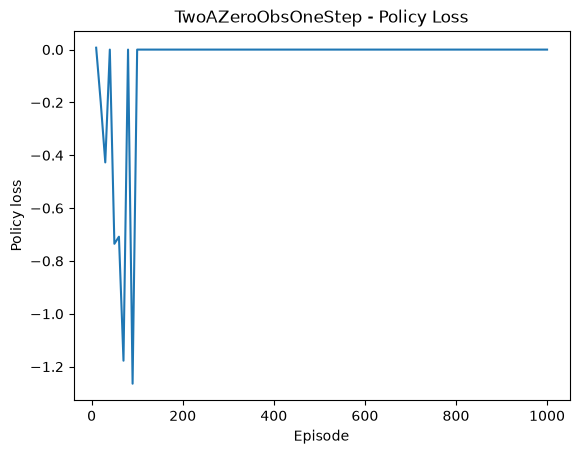

In [10]:
plt.plot(
    history["loss_steps"],
    history["losses"]
)

plt.xlabel("Episode")
plt.ylabel("Policy loss")
plt.title("TwoAZeroObsOneStep - Policy Loss")
plt.show()

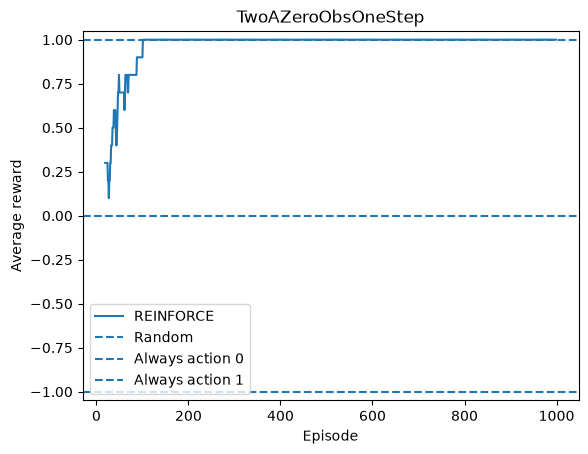

In [11]:
rewards = np.array(history["rewards"])

window = 20
moving_avg = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    np.arange(window - 1, len(rewards)),
    moving_avg,
    label="REINFORCE"
)

plt.axhline(0, linestyle="--", label="Random")
plt.axhline(1, linestyle="--", label="Always action 0")
plt.axhline(-1, linestyle="--", label="Always action 1")

plt.xlabel("Episode")
plt.ylabel("Average reward")
plt.title("TwoAZeroObsOneStep")
plt.ylim(-1.05, 1.05)
plt.legend()
plt.show()

### TwoARandomObsOneStep

In [12]:
env = TwoARandomObsOneStep()

policy, history = train_reinforce(
    env,
    num_episodes=1000,
    batch_size=10,
    gamma=0.99,
    learning_rate=1e-2,
)

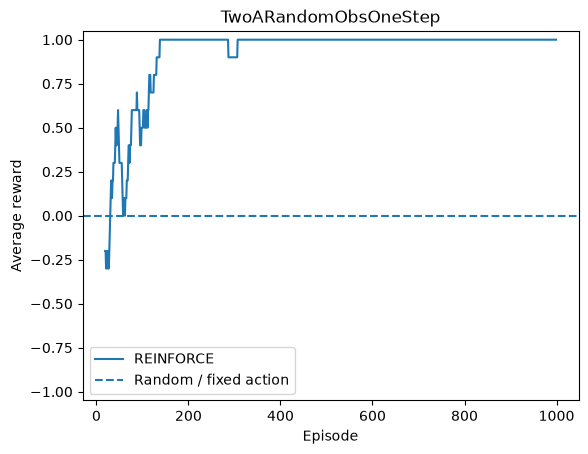

In [13]:
rewards = np.array(history["rewards"])

window = 20
moving_avg = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    np.arange(window - 1, len(rewards)),
    moving_avg,
    label="REINFORCE"
)

plt.axhline(0, linestyle="--", label="Random / fixed action")

plt.xlabel("Episode")
plt.ylabel("Average reward")
plt.title("TwoARandomObsOneStep")
plt.ylim(-1.05, 1.05)
plt.legend()
plt.show()

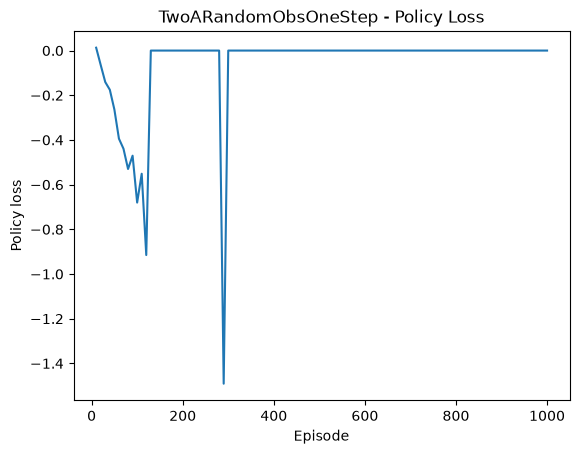

In [14]:
plt.plot(
    history["loss_steps"],
    history["losses"]
)

plt.xlabel("Episode")
plt.ylabel("Policy loss")
plt.title("TwoARandomObsOneStep - Policy Loss")
plt.show()

In [15]:
for obs in [0, 1]:
    state = observation_to_tensor(
        obs,
        env.observation_space
    )

    with torch.no_grad():
        logits = policy(state)
        probs = torch.softmax(logits, dim=-1)

    print(f"Estado {obs}: {probs.numpy()}")

Estado 0: [9.9998784e-01 1.2191839e-05]
Estado 1: [1.3027612e-05 9.9998701e-01]


### LineWorldEasyEnv

In [16]:
env = LineWorldEasyEnv()

policy, history = train_reinforce(
    env,
    num_episodes=2000,
    batch_size=10,
    gamma=0.99,
    learning_rate=1e-2,
)

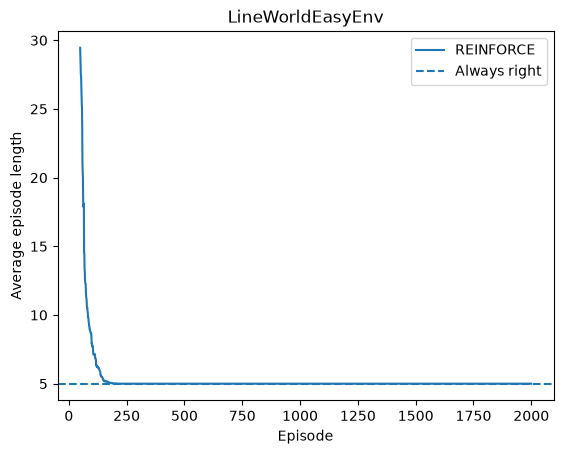

In [17]:
lengths = np.array(history["lengths"])

window = 50
moving_avg_length = np.convolve(
    lengths,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    np.arange(window - 1, len(lengths)),
    moving_avg_length,
    label="REINFORCE"
)

plt.axhline(5, linestyle="--", label="Always right")

plt.xlabel("Episode")
plt.ylabel("Average episode length")
plt.title("LineWorldEasyEnv")
plt.legend()
plt.show()

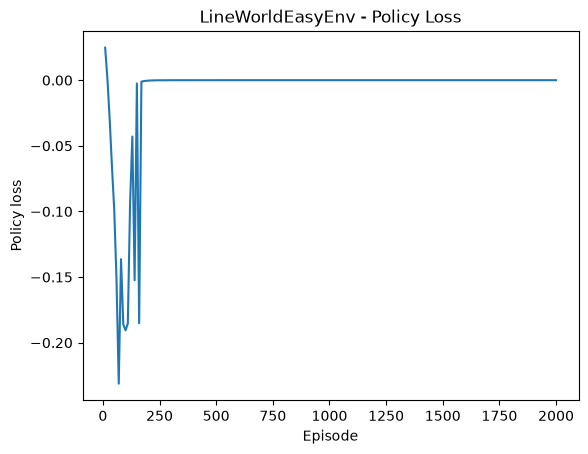

In [18]:
plt.plot(
    history["loss_steps"],
    history["losses"]
)

plt.xlabel("Episode")
plt.ylabel("Policy loss")
plt.title("LineWorldEasyEnv - Policy Loss")
plt.show()

In [19]:
for obs in range(5):
    state = observation_to_tensor(
        obs,
        env.observation_space
    )

    with torch.no_grad():
        logits = policy(state)
        probs = torch.softmax(logits, dim=-1)

    print(f"Estado {obs}: {probs.numpy()}")

Estado 0: [9.426325e-06 9.999906e-01]
Estado 1: [1.6744070e-06 9.9999833e-01]
Estado 2: [5.593573e-07 9.999994e-01]
Estado 3: [1.5953005e-06 9.9999845e-01]
Estado 4: [4.0567994e-07 9.9999964e-01]
